# 01 — Data Quality Overview

Runs completeness, validity and uniqueness checks over the Olist + synthetic sources and computes an overall **Data Quality score** — the local, pandas-based preview of what `data_quality/` (GX Core, Sprint 3) does for real against Databricks Silver tables. See `ARCHITECTURE.md §7` and `docs/decisions/ADR-009-dataset-strategy.md` for why the synthetic data is deliberately dirty.

Run `make seed` from the repo root before running this notebook.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OLIST_DIR = ROOT / "data" / "raw" / "olist"
SYNTH_DIR = ROOT / "data" / "synthetic"

# The Olist dataset requires an interactive Kaggle login (`make download-olist`) and may not
# be present in every environment — the platform is designed to degrade gracefully without it
# (ADR-009), so this notebook checks for it but does not hard-require it. The synthetic CRM
# data is always required (`make seed`, no login needed).
required = [
    SYNTH_DIR / "crm" / "crm_customers.csv",
    SYNTH_DIR / "crm" / "crm_customers_ground_truth.csv",
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing input file(s):\n  " + "\n  ".join(missing) +
        "\n\nRun `make seed` from the repo root first — see DATA_MODEL.md."
    )

HAS_OLIST = (OLIST_DIR / "olist_customers_dataset.csv").exists() and (OLIST_DIR / "olist_orders_dataset.csv").exists()
print("All required (synthetic) input files found.")
print(f"Olist dataset present: {HAS_OLIST}" + ("" if HAS_OLIST else " — run `make download-olist` to add it; this notebook runs fine without it."))

All required (synthetic) input files found.
Olist dataset present: False — run `make download-olist` to add it; this notebook runs fine without it.


In [2]:
if HAS_OLIST:
    olist_customers = pd.read_csv(OLIST_DIR / "olist_customers_dataset.csv")
    olist_orders = pd.read_csv(OLIST_DIR / "olist_orders_dataset.csv")
else:
    olist_customers = olist_orders = None

crm = pd.read_csv(SYNTH_DIR / "crm" / "crm_customers.csv")
crm_ground_truth = pd.read_csv(SYNTH_DIR / "crm" / "crm_customers_ground_truth.csv")

if HAS_OLIST:
    print(f"olist_customers: {len(olist_customers):,} rows")
    print(f"olist_orders:    {len(olist_orders):,} rows")
else:
    print("olist_customers / olist_orders: skipped (Olist not downloaded)")
print(f"crm:              {len(crm):,} rows ({len(crm_ground_truth):,} deliberate duplicates)")

olist_customers / olist_orders: skipped (Olist not downloaded)
crm:              10,500 rows (500 deliberate duplicates)


## Completeness

Null rate per key column. `crm.email` and `crm.phone` are expected to show a non-zero null/invalid rate — see `data/synthetic/config.yaml` `dirty_rates`.

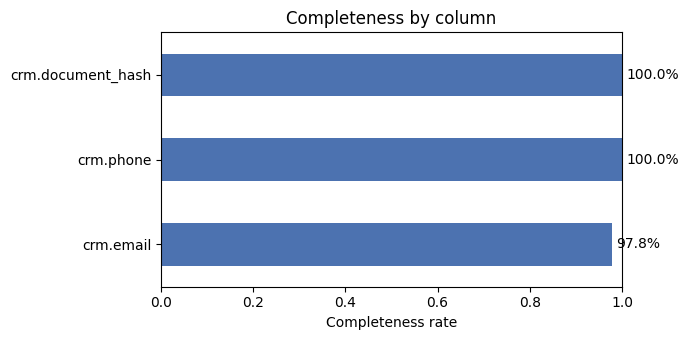

In [3]:
completeness_targets = {
    "crm.email": crm["email"],
    "crm.phone": crm["phone"],
    "crm.document_hash": crm["document_hash"],
}
if HAS_OLIST:
    completeness_targets = {
        "olist_customers.customer_id": olist_customers["customer_id"],
        "olist_orders.order_id": olist_orders["order_id"],
        **completeness_targets,
    }
completeness = {
    name: 1 - series.isna().mean() for name, series in completeness_targets.items()
}
completeness_df = pd.Series(completeness).sort_values()

ax = completeness_df.plot.barh(figsize=(7, 3.5), color="#4C72B0")
ax.set_xlim(0, 1)
ax.set_xlabel("Completeness rate")
ax.set_title("Completeness by column")
for i, v in enumerate(completeness_df):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.show()

## Validity

Simple regex-based format checks — a lightweight stand-in for the real GX Core `Expectation`s in `data_quality/expectations/`.

In [4]:
EMAIL_RE = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")

valid_email = crm["email"].dropna().apply(lambda x: bool(EMAIL_RE.match(str(x))))
email_validity = valid_email.mean() if len(valid_email) else float("nan")

# phone is considered valid if it has at least 8 digits (see generators/crm.py —
# invalid phones are truncated to <=4 digits on purpose)
digit_count = crm["phone"].astype(str).str.replace(r"\D", "", regex=True).str.len()
phone_validity = (digit_count >= 8).mean()

print(f"Email format validity: {email_validity:.1%} (of non-null emails)")
print(f"Phone format validity: {phone_validity:.1%}")

Email format validity: 100.0% (of non-null emails)
Phone format validity: 98.9%


## Uniqueness / duplicate detection

`order_id` must be unique in Olist; the CRM table is expected to contain the deliberately-injected near-duplicates counted in `crm_customers_ground_truth.csv` — this is exactly what `mdm/` (notebook 02) is built to resolve.

In [5]:
crm_duplicate_rate = len(crm_ground_truth) / len(crm)

if HAS_OLIST:
    order_id_uniqueness = 1 - olist_orders["order_id"].duplicated().mean()
    print(f"olist_orders.order_id uniqueness: {order_id_uniqueness:.2%}")
else:
    # No Olist order_id to check here — use crm document_hash uniqueness as the
    # equivalent "should be unique" check on the data we do have.
    order_id_uniqueness = 1 - crm["document_hash"].dropna().duplicated().mean()
    print(f"crm.document_hash uniqueness (Olist not available, using this instead): {order_id_uniqueness:.2%}")

print(f"crm known duplicate rate:         {crm_duplicate_rate:.2%} "
      f"({len(crm_ground_truth)} of {len(crm)} rows)")

crm.document_hash uniqueness (Olist not available, using this instead): 95.10%
crm known duplicate rate:         4.76% (500 of 10500 rows)


## Overall Data Quality score

A simple weighted average across the dimensions above — the real platform's `dq_score` (see `data_quality/README.md`) is computed per-table by GX Checkpoints and rolled up the same way, just with a full Expectation Suite instead of these five ad-hoc checks.

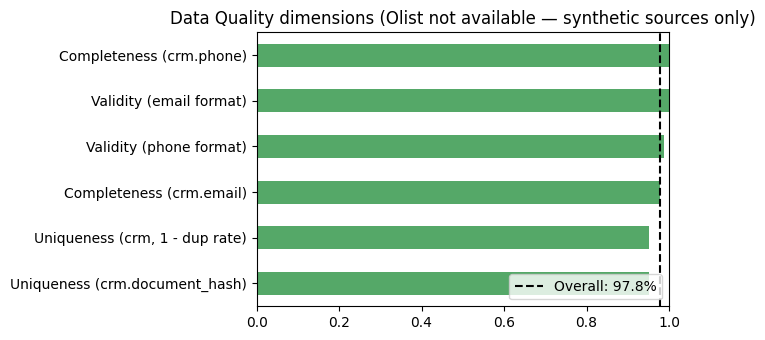


Overall DQ score: 97.8%


In [6]:
scores = {
    "Completeness (crm.email)": completeness["crm.email"],
    "Completeness (crm.phone)": completeness["crm.phone"],
    "Validity (email format)": email_validity,
    "Validity (phone format)": phone_validity,
    "Uniqueness (order_id)" if HAS_OLIST else "Uniqueness (crm.document_hash)": order_id_uniqueness,
    "Uniqueness (crm, 1 - dup rate)": 1 - crm_duplicate_rate,
}
overall_dq_score = pd.Series(scores).mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
pd.Series(scores).sort_values().plot.barh(ax=ax, color="#55A868")
ax.axvline(overall_dq_score, color="black", linestyle="--", label=f"Overall: {overall_dq_score:.1%}")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
ax.set_title("Data Quality dimensions" + ("" if HAS_OLIST else " (Olist not available — synthetic sources only)"))
plt.tight_layout()
plt.show()

print(f"\nOverall DQ score: {overall_dq_score:.1%}")

## Maps to the real pipeline

- `data_quality/expectations/` — the real GX Core Expectation Suites this notebook approximates.
- `data_quality/validators/` — Checkpoints that quarantine failing rows instead of just reporting a score.
- Power BI "Data Quality" page (`powerbi/`, ARCHITECTURE.md §13) — the same score, presented to business users.
- `06_platform_kpis_dashboard.ipynb` — includes this DQ score alongside business KPIs.